# Task 2 — Classificazione BBC News (9 classi)


## 1. Import e caricamento dati


In [1]:
import pandas as pd
import numpy as np
from collections import Counter  # utile per conteggi frequenze

import nltk
nltk.download('stopwords', quiet=True)  # stopwords per rimozione parole comuni

from nltk.tokenize import RegexpTokenizer
from nltk import FreqDist               # distribuzione frequenze token
from nltk.corpus import stopwords       # lista stopwords

# Tokenizer basato su regex: estrae solo parole (token alfanumerici)
_tokenizer = RegexpTokenizer(r'\w+')

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    f1_score
)

import matplotlib.pyplot as plt

# Caricamento dataset (versione a 9 classi)
df = pd.read_csv("bbc_dataset_9classi.csv")

# Informazioni base sul dataset
print(f"Dataset: {df.shape[0]} articoli, {df.shape[1]} colonne")

# Distribuzione delle classi nel dataset
print(f"\nDistribuzione classi:\n{df['label'].value_counts()}")

# Anteprima del dataset
df.head()

Dataset: 7049 articoli, 4 colonne

Distribuzione classi:
label
tennis               1000
other_sport          1000
rugby                1000
cricket              1000
non_sport            1000
football             1000
formula1              462
american_football     333
golf                  254
Name: count, dtype: int64


,title,text,label,url
0,Sabalenka takes on Pegula and crowd in US Open...,Aryna Sabalenka will have to deal with a boist...,tennis,https://www.bbc.com/sport/tennis/articles/cvg3...
1,From winning iPods to Grand Slams - Djokovic's...,Novak Djokovic continues to reach landmarks mo...,tennis,https://www.bbc.com/sport/tennis/articles/cdd4...
2,Chalmers targets World final after new persona...,Alastair Chalmers says he is targeting the 400...,other_sport,https://www.bbc.com/sport/athletics/articles/c...
3,Players flee court after UAE drone attack caus...,Players and officials ran from the court at an...,tennis,https://www.bbc.com/sport/tennis/articles/cx2g...
4,How will GB cope without Raducanu in BJK Cup?,Great Britain's Billie Jean King Cup captain A...,tennis,https://www.bbc.com/sport/tennis/videos/c79vq8...


## 2. Pre-processing: tokenizzazione e rimozione stopwords


In [2]:
# Insieme delle stopwords inglesi (set per accesso più veloce)
STOP_WORDS = set(stopwords.words("english"))

def tokenizza_e_pulisci(testo: str) -> list[str]:
    # Tokenizzazione + conversione in minuscolo
    tokens = _tokenizer.tokenize(testo.lower())

    # Filtraggio dei token
    return [
        t for t in tokens
        if t.isalpha()            # solo parole alfabetiche
        and t not in STOP_WORDS   # rimozione stopwords
        and len(t) > 2            # rimozione token troppo corti
    ]

# Applicazione della tokenizzazione all'intero dataset
df["tokens"] = df["text"].apply(tokenizza_e_pulisci)

# Esempio di output per verifica
print(f"Esempio tokens: {df.iloc[0]['tokens'][:15]}")

Esempio tokens: ['aryna', 'sabalenka', 'deal', 'boisterous', 'new', 'york', 'crowd', 'faces', 'home', 'hope', 'jessica', 'pegula', 'saturday', 'open', 'final']


## 3. Split train/test


In [3]:
# Split del dataset in train e test
df_train, df_test = train_test_split(
    df,
    test_size=0.2,            # 20% test set
    random_state=42,          # riproducibilità
    stratify=df["label"]      # mantiene distribuzione classi
)

# Dimensioni dei dataset
print(f"Train: {len(df_train)} | Test: {len(df_test)}")

# Distribuzione delle classi nel training set
print(f"\nDistribuzione train:\n{df_train['label'].value_counts()}")

Train: 5639 | Test: 1410

Distribuzione train:
label
other_sport          800
tennis               800
non_sport            800
football             800
rugby                800
cricket              800
formula1             370
american_football    266
golf                 203
Name: count, dtype: int64


## 4. Analisi frequenze con FreqDist (per classe)

Con 9 classi calcoliamo una `FreqDist` separata per ciascuna. Per ogni parola il **rapporto di appartenenza** a una classe è: `freq_classe / freq_totale`.


In [4]:
# Lista delle classi presenti nel dataset (9 classi totali)
CLASSI = [
    'non_sport', 'football', 'tennis', 'rugby',
    'cricket', 'other_sport', 'formula1',
    'american_football', 'golf'
]

# Dizionario che conterrà la FreqDist per ogni classe
fd = {}

# Costruzione delle distribuzioni di frequenza per classe (solo training set)
for cls in CLASSI:
    tokens_cls = []

    # Filtra il dataset per classe corrente e raccoglie i token
    for _, riga in df_train[df_train["label"] == cls].iterrows():
        tokens_cls.extend(riga["tokens"])

    # Calcolo distribuzione di frequenza dei token della classe
    fd[cls] = FreqDist(tokens_cls)

    # Stampa statistiche della classe
    print(
        f"  {cls:<20s}  {len(fd[cls]):,} parole uniche  "
        f"({sum(fd[cls].values()):,} token)"
    )

  non_sport             40,299 parole uniche  (435,298 token)
  football              17,086 parole uniche  (187,048 token)
  tennis                14,664 parole uniche  (266,608 token)
  rugby                 15,603 parole uniche  (241,724 token)
  cricket               11,882 parole uniche  (170,764 token)
  other_sport           18,691 parole uniche  (222,265 token)
  formula1              9,737 parole uniche  (152,066 token)
  american_football     8,625 parole uniche  (93,377 token)
  golf                  8,196 parole uniche  (67,183 token)


## 5. Selezione keyword discriminanti per classe

Per ogni parola con frequenza totale ≥ 30, calcoliamo il rapporto su ogni classe. Se il rapporto ≥ 0.60 quella parola è una keyword di quella classe.


In [ ]:
# Soglie per selezione keyword
SOGLIA_FREQ_MIN = 30       # frequenza minima totale per considerare una parola
SOGLIA_RATIO    = 0.60     # percentuale minima per assegnare una parola a una classe

# Unione di tutti i vocaboli presenti nelle diverse classi
vocabolario = set()
for cls in CLASSI:
    vocabolario |= set(fd[cls].keys())

# Dizionario: per ogni classe, insieme delle keyword discriminanti
keyword_per_classe = {cls: set() for cls in CLASSI}

# Analisi parola per parola nel vocabolario globale
for parola in vocabolario:

    # Frequenza della parola per ciascuna classe
    freq_per_cls = {cls: fd[cls][parola] for cls in CLASSI}

    # Frequenza totale della parola su tutte le classi
    totale = sum(freq_per_cls.values())

    # Scarta parole troppo rare
    if totale < SOGLIA_FREQ_MIN:
        continue

    # Assegna la parola alla classe dominante (se supera la soglia)
    for cls in CLASSI:
        if freq_per_cls[cls] / totale >= SOGLIA_RATIO:
            keyword_per_classe[cls].add(parola)

# Stampa numero di keyword per classe
for cls in CLASSI:
    print(f"  {cls:<20s}  {len(keyword_per_classe[cls]):4d} keyword")

## 6. Classificatore Rule-Based (multiclasse)

Per ogni articolo contiamo le keyword di ciascuna classe. La classe con il punteggio più alto vince. In caso di pareggio totale → `non_sport`.


In [ ]:
def classificatore_rule_based(tokens: list[str], kw: dict) -> str:
    # Calcola un punteggio per ogni classe:
    # numero di token presenti nelle keyword della classe
    punteggi = {
        cls: sum(1 for t in tokens if t in kw[cls])
        for cls in CLASSI
    }

    # Classe con punteggio massimo
    best_cls = max(punteggi, key=punteggi.get)

    # Se nessuna keyword matcha, fallback a 'non_sport'
    if punteggi[best_cls] == 0:
        return "non_sport"

    return best_cls


# Copia del test set per evitare modifiche al dataframe originale
df_test = df_test.copy()

# Applicazione del classificatore rule-based
df_test["predizione"] = df_test["tokens"].apply(
    lambda t: classificatore_rule_based(t, keyword_per_classe)
)

# Esempi di predizione
print("Esempi di predizione:")
for _, riga in df_test.head(10).iterrows():
    ok = "✓" if riga["predizione"] == riga["label"] else "✗"
    print(
        f"  {ok} vero={riga['label']:20s}  "
        f"pred={riga['predizione']:20s}  "
        f"{riga['title'][:50]}"
    )

Esempi di predizione:
  ✓ vero=football              pred=football              Blackpool sign Walters, Anderson and Clarkson
  ✓ vero=american_football     pred=american_football     What's behind the Irish impact in the NFL?
  ✓ vero=non_sport             pred=non_sport             Five lifestyle tweaks to help you live well for lo
  ✓ vero=tennis                pred=tennis                GB's Salisbury & Skupski reach Paris doubles final
  ✓ vero=rugby                 pred=rugby                 The father-son dynasties powering England's future
  ✓ vero=non_sport             pred=non_sport             'I can't breathe any more': Inside the night a mob
  ✓ vero=golf                  pred=golf                  The golfer who scored 10 on one hole in The Open
  ✓ vero=rugby                 pred=rugby                 Wales U20s aim to provide hope in 'dark time'
  ✓ vero=american_football     pred=american_football     Who are the NFL's play-off contenders and pretende
  ✓ vero=rugby   

## 7. Valutazione Baseline


In [ ]:
# Ground truth (etichette reali) e predizioni del modello
y_true = df_test["label"]
y_pred = df_test["predizione"]

# Classification report: precision, recall, f1-score per ogni classe
# target_names ordinato alfabeticamente per coerenza tra classi
print(
    classification_report(
        y_true,
        y_pred,
        target_names=sorted(df["label"].unique())
    )
)

                   precision    recall  f1-score   support

american_football       0.95      0.91      0.93        67
          cricket       0.99      0.98      0.99       200
         football       0.98      0.82      0.89       200
         formula1       0.92      0.99      0.95        92
             golf       0.96      0.92      0.94        51
        non_sport       0.76      0.99      0.86       200
      other_sport       0.99      0.76      0.86       200
            rugby       0.95      0.98      0.97       200
           tennis       0.94      0.98      0.96       200

         accuracy                           0.92      1410
        macro avg       0.94      0.93      0.93      1410
     weighted avg       0.93      0.92      0.92      1410



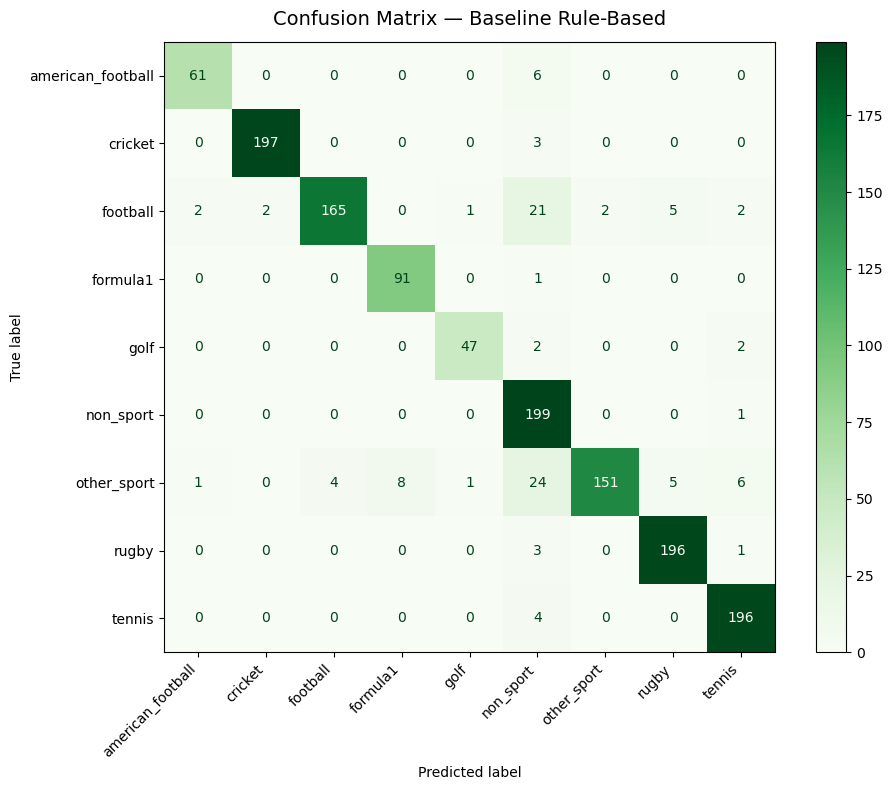

In [ ]:
import os

# Ordinamento delle etichette per mantenere coerenza nella confusion matrix
labels_ord = sorted(df["label"].unique())

# Calcolo della matrice di confusione
cm = confusion_matrix(y_true, y_pred, labels=labels_ord)

# Creazione figura
fig, ax = plt.subplots(figsize=(10, 8))

# Visualizzazione confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels_ord)
disp.plot(cmap="Greens", ax=ax, values_format="d")

# Titolo del grafico
ax.set_title("Confusion Matrix — Baseline Rule-Based", fontsize=14, pad=12)

# Rotazione etichette asse X per leggibilità
plt.xticks(rotation=45, ha='right')

plt.tight_layout()

# Creazione directory output se non esiste
os.makedirs("output", exist_ok=True)

# Salvataggio immagine
plt.savefig("output/confusion_matrix_baseline.png", dpi=150)

# Visualizzazione grafico
plt.show()

### Perché la baseline rule-based funziona a 0.92

- **Cattura del segnale facile**: le 9 classi hanno vocabolari molto distinti (nomi di squadre, giocatori, termini tecnici). Un classificatore che conta semplicemente le keyword discriminanti prende il 92% di accuracy.
- **Problemi visibili nella matrice**:
  - `non_sport` ha precision bassa (0.76): ha 1122 keyword (contro 56 di `golf`, 181 di `football`), quindi vince molti "pareggi" e assorbe articoli di altre classi.
  - `other_sport` ha recall bassa (0.76): è un catch-all linguisticamente eterogeneo.
- **Limite strutturale**: conteggio 0/1 senza pesi — una parola generica vale quanto un nome proprio discriminante.


## 8. Regressione Logistica con TF-IDF

Pipeline TF-IDF + `LogisticRegression`. 


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

# Feature (testo grezzo) per training e test
X_train = df_train["text"]
X_test_text = df_test["text"]

# Label per training e test
y_train_lr = df_train["label"]
y_test_lr  = df_test["label"]

# Pipeline: TF-IDF + Regressione Logistica
pipeline_lr = Pipeline([
    ("tfidf", TfidfVectorizer(
        tokenizer=tokenizza_e_pulisci,   # tokenizer personalizzato
        token_pattern=None,              # disattiva tokenizer di default
        max_features=10_000,             # limita vocabolario
        sublinear_tf=True,               # scaling logaritmico delle frequenze
    )),
    ("lr", LogisticRegression(
        max_iter=1000,                   # iterazioni massime per convergenza
        random_state=42,                 # riproducibilità
    )),
])

# Addestramento del modello
pipeline_lr.fit(X_train, y_train_lr)

print("Training completato.")

Training completato.


## 9. Valutazione Regressione Logistica


In [ ]:
# Predizioni del modello Logistic Regression sul test set
y_pred_lr = pipeline_lr.predict(X_test_text)

# Classification report del modello supervisionato (TF-IDF + Logistic Regression)
print("=== Classification Report — Logistic Regression ===")
print(
    classification_report(
        y_test_lr,
        y_pred_lr,
        target_names=sorted(df["label"].unique())
    )
)

=== Classification Report — Logistic Regression ===
                   precision    recall  f1-score   support

american_football       1.00      0.94      0.97        67
          cricket       1.00      0.99      1.00       200
         football       0.99      0.97      0.98       200
         formula1       0.99      0.97      0.98        92
             golf       0.98      0.96      0.97        51
        non_sport       0.93      0.99      0.96       200
      other_sport       0.97      0.95      0.96       200
            rugby       0.99      0.99      0.99       200
           tennis       0.99      0.99      0.99       200

         accuracy                           0.98      1410
        macro avg       0.98      0.97      0.98      1410
     weighted avg       0.98      0.98      0.98      1410



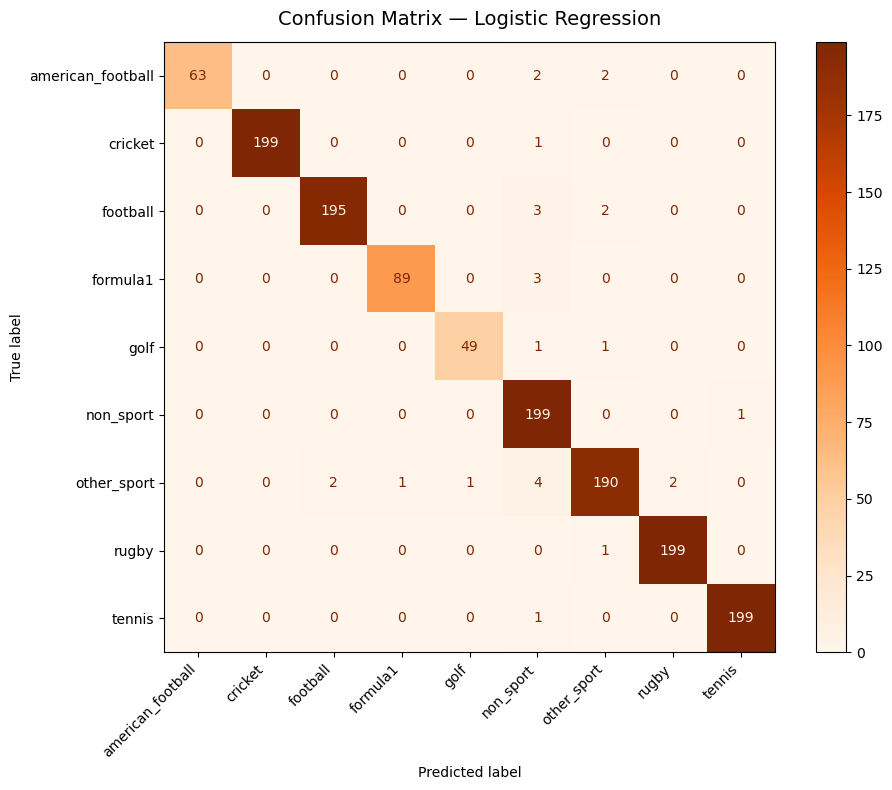

In [ ]:
import os

# Confusion matrix per il modello Logistic Regression
cm_lr = confusion_matrix(y_test_lr, y_pred_lr, labels=labels_ord)

# Creazione figura
fig, ax = plt.subplots(figsize=(10, 8))

# Visualizzazione confusion matrix
ConfusionMatrixDisplay(
    confusion_matrix=cm_lr,
    display_labels=labels_ord
).plot(cmap="Oranges", ax=ax, values_format="d")

# Titolo del grafico
ax.set_title("Confusion Matrix — Logistic Regression", fontsize=14, pad=12)

# Miglioramento leggibilità etichette asse X
plt.xticks(rotation=45, ha='right')

plt.tight_layout()

# Creazione cartella output se non esiste
os.makedirs("output", exist_ok=True)

# Salvataggio immagine
plt.savefig("output/confusion_matrix_lr.png", dpi=150)

# Visualizzazione
plt.show()

### Perché la Logistic Regression è così forte (0.98)

- **TF-IDF + LR** è un baseline adatta per text classification: con 9 classi scikit-learn usa automaticamente la softmax (logistic regression multinomiale).
- La **regolarizzazione L2** (default `C=1.0`) previene overfitting anche con 10 000 feature.
- Supera di poco il baseline rule-based (0.98 vs 0.92) perché:
  - usa tutte le parole (non solo quelle selezionate sopra threshold)
  - pesa ciascuna con TF-IDF
  - apprende i pesi ottimali per massimizzare l'accuratezza, invece di usare rapporti fissi


## 10. Rete Neurale Feedforward

Architettura a 2 layer (come da slide):
- **Hidden layer**: `h = ReLU(Wx + b)`
- **Output layer**: `softmax(Uh)` — 9 neuroni di uscita, uno per classe
- **Loss**: Cross-Entropy (generalizzazione a N classi della binary cross-entropy)
- **Ottimizzatore**: SGD


In [ ]:
import torch
import torch.nn as nn

# Seed per riproducibilità dei risultati
torch.manual_seed(42)

from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import LabelEncoder

# ── TF-IDF ──
# Trasformazione del testo in vettori numerici (feature)
tfidf_nn = TfidfVectorizer(
    tokenizer=tokenizza_e_pulisci,  # tokenizer personalizzato
    token_pattern=None,             # disattiva tokenizer di default
    max_features=10_000,            # limita dimensione vocabolario
    sublinear_tf=True,              # scaling logaritmico
)

# Fit sul train + trasformazione in array numpy float32 (compatibile con PyTorch)
X_train_tfidf = tfidf_nn.fit_transform(X_train).toarray().astype(np.float32)

# Trasformazione del test usando lo stesso vocabolario
X_test_tfidf  = tfidf_nn.transform(X_test_text).toarray().astype(np.float32)

# ── Label Encoding ──
# Conversione delle etichette da stringhe a interi
le = LabelEncoder()

y_train_enc = le.fit_transform(y_train_lr).astype(np.int64)
y_test_enc  = le.transform(y_test_lr).astype(np.int64)

# Numero di classi
N_CLASSI = len(le.classes_)
print(f"Classi ({N_CLASSI}): {list(le.classes_)}")

# ── Dataset PyTorch ──
# Creazione dataset con feature e label
train_dataset = TensorDataset(
    torch.tensor(X_train_tfidf),  # feature TF-IDF
    torch.tensor(y_train_enc)     # label codificate
)

# DataLoader: batching + shuffle per training
train_loader = DataLoader(
    train_dataset,
    batch_size=32,  # dimensione batch
    shuffle=True    # mescola i dati ad ogni epoca
)

Classi (9): ['american_football', 'cricket', 'football', 'formula1', 'golf', 'non_sport', 'other_sport', 'rugby', 'tennis']


In [ ]:
class FeedforwardNN(nn.Module):
    
    def __init__(self, input_dim: int, hidden_dim: int, n_classi: int):
        super().__init__()

        # Layer fully-connected: input → hidden
        self.hidden = nn.Linear(input_dim, hidden_dim)

        # Layer fully-connected: hidden → output (logits per classe)
        self.output = nn.Linear(hidden_dim, n_classi)

        # Funzione di attivazione non lineare
        self.act = nn.Tanh()

    def forward(self, x):
        # Passaggio attraverso hidden layer + attivazione
        h = self.act(self.hidden(x))

        # Output layer (senza softmax: incluso in CrossEntropyLoss)
        return self.output(h)


# Dimensioni del modello
INPUT_DIM  = X_train_tfidf.shape[1]  # numero di feature TF-IDF
HIDDEN_DIM = 512                     # numero neuroni hidden layer
LR         = 0.01                    # learning rate
EPOCHS     = 30                      # numero epoche di training

# Inizializzazione modello
model_sgd = FeedforwardNN(INPUT_DIM, HIDDEN_DIM, N_CLASSI)

# Funzione di loss (include softmax internamente)
criterion_sgd = nn.CrossEntropyLoss()

# Ottimizzatore SGD
optimizer_sgd = torch.optim.SGD(
    model_sgd.parameters(),
    lr=LR
)

# Stampa architettura del modello
print(model_sgd)

# Numero totale di parametri allenabili
print(f"Parametri totali: {sum(p.numel() for p in model_sgd.parameters()):,}")

FeedforwardNN(
  (hidden): Linear(in_features=10000, out_features=512, bias=True)
  (output): Linear(in_features=512, out_features=9, bias=True)
  (act): Tanh()
)
Parametri totali: 5,125,129


In [ ]:
# Imposta il modello in modalità training (attiva dropout, batchnorm, ecc. se presenti)
model_sgd.train()

# Loop sulle epoche
for epoch in range(1, EPOCHS + 1):
    total_loss = 0.0  # accumulatore loss totale per epoca

    # Iterazione sui batch
    for X_batch, y_batch in train_loader:

        optimizer_sgd.zero_grad()  # reset gradienti

        # Forward + calcolo loss
        loss = criterion_sgd(model_sgd(X_batch), y_batch)

        # Backpropagation
        loss.backward()

        # Aggiornamento pesi
        optimizer_sgd.step()

        # Accumula la loss pesata per dimensione batch
        total_loss += loss.item() * len(y_batch)

    # Loss media sull'intero dataset di training
    print(f"Epoch {epoch:2d}/{EPOCHS}  |  loss: {total_loss / len(train_dataset):.4f}")

print("Training completato.")

Epoch  1/30  |  loss: 2.1827
Epoch  2/30  |  loss: 2.1520
Epoch  3/30  |  loss: 2.1310
Epoch  4/30  |  loss: 2.1159
Epoch  5/30  |  loss: 2.1046
Epoch  6/30  |  loss: 2.0958
Epoch  7/30  |  loss: 2.0886
Epoch  8/30  |  loss: 2.0822
Epoch  9/30  |  loss: 2.0762
Epoch 10/30  |  loss: 2.0704
Epoch 11/30  |  loss: 2.0646
Epoch 12/30  |  loss: 2.0585
Epoch 13/30  |  loss: 2.0520
Epoch 14/30  |  loss: 2.0451
Epoch 15/30  |  loss: 2.0375
Epoch 16/30  |  loss: 2.0294
Epoch 17/30  |  loss: 2.0203
Epoch 18/30  |  loss: 2.0105
Epoch 19/30  |  loss: 1.9997
Epoch 20/30  |  loss: 1.9878
Epoch 21/30  |  loss: 1.9748
Epoch 22/30  |  loss: 1.9604
Epoch 23/30  |  loss: 1.9447
Epoch 24/30  |  loss: 1.9276
Epoch 25/30  |  loss: 1.9089
Epoch 26/30  |  loss: 1.8884
Epoch 27/30  |  loss: 1.8663
Epoch 28/30  |  loss: 1.8425
Epoch 29/30  |  loss: 1.8169
Epoch 30/30  |  loss: 1.7895
Training completato.


## 11. Valutazione NN


In [ ]:
# Modalità evaluation (disattiva dropout, batchnorm, ecc.)
model_sgd.eval()

# Disabilita il calcolo dei gradienti (più efficiente in inference)
with torch.no_grad():

    # Forward pass sul test set
    logits = model_sgd(torch.tensor(X_test_tfidf))

    # Predizione: indice della classe con valore massimo (argmax)
    y_pred_nn_sgd_enc = logits.argmax(dim=1).numpy()

# Conversione etichette da interi a stringhe originali
y_pred_nn_sgd = le.inverse_transform(y_pred_nn_sgd_enc)

print("=== Classification Report — NN Feedforward ===")

# Valutazione modello (precision, recall, f1-score per classe)
print(
    classification_report(
        y_test_lr,
        y_pred_nn_sgd,
        target_names=sorted(df["label"].unique())
    )
)

=== Classification Report — NN Feedforward ===
                   precision    recall  f1-score   support

american_football       0.00      0.00      0.00        67
          cricket       0.96      0.99      0.97       200
         football       0.86      0.92      0.88       200
         formula1       0.00      0.00      0.00        92
             golf       0.00      0.00      0.00        51
        non_sport       0.58      0.99      0.74       200
      other_sport       0.76      0.73      0.75       200
            rugby       0.87      0.94      0.90       200
           tennis       0.84      0.99      0.91       200

         accuracy                           0.79      1410
        macro avg       0.54      0.62      0.57      1410
     weighted avg       0.69      0.79      0.73      1410



/opt/miniconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/miniconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/miniconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


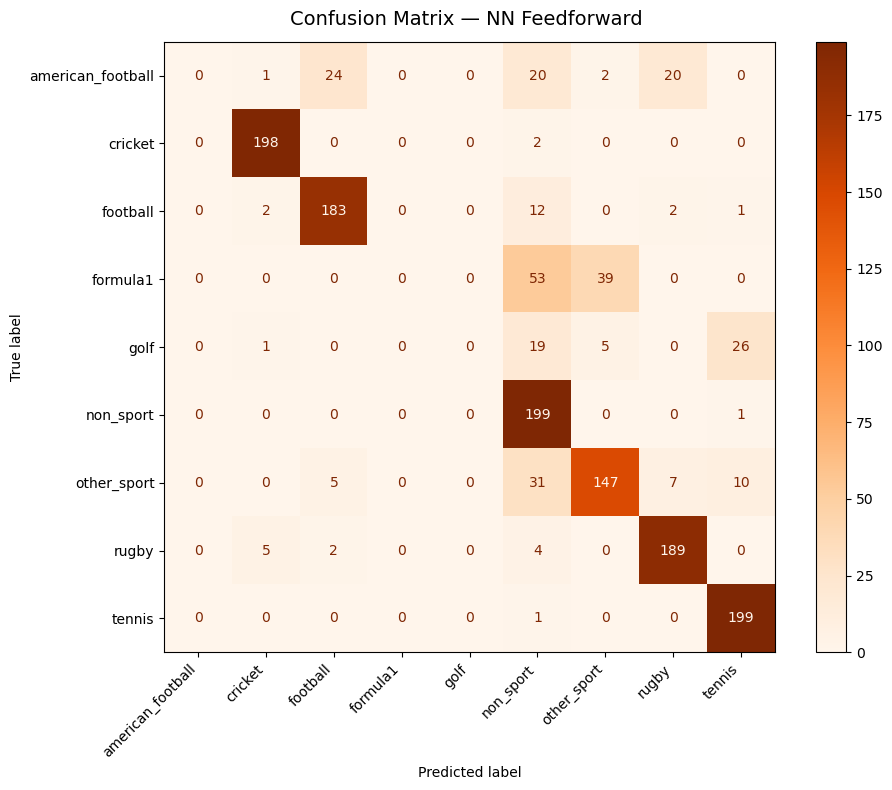

In [ ]:
# Calcolo confusion matrix per il modello NN
cm_nn = confusion_matrix(y_test_lr, y_pred_nn_sgd, labels=labels_ord)

# Creazione figura
fig, ax = plt.subplots(figsize=(10, 8))

# Visualizzazione confusion matrix
ConfusionMatrixDisplay(
    confusion_matrix=cm_nn,
    display_labels=labels_ord
).plot(cmap="Oranges", ax=ax, values_format="d")

# Titolo del grafico
ax.set_title("Confusion Matrix — NN Feedforward ", fontsize=14, pad=12)

# Rotazione etichette asse X per leggibilità
plt.xticks(rotation=45, ha='right')

plt.tight_layout()

# Salvataggio immagine (assume che la cartella 'output' esista già)
plt.savefig("output/confusion_matrix_nn.png", dpi=150)

# Visualizzazione grafico
plt.show()

### Perché SGD fallisce miseramente

- Con `lr=0.01` + `Tanh` su input TF-IDF sparso (molte feature a zero), i gradienti sono **troppo piccoli**: in 30 epoche la loss scende solo da 2.18 a 1.79.
- Tre classi (`american_football`, `formula1`, `golf`), ovvero le **classi minoritarie** con meno esempi nel train, non vengono mai predette → F1 = 0.00 su di esse.
- **Inoltre, non mettendo EarlyStopping, il modello impara più del dovuto, aumentando moltissimo l'errore e la propria precisione.**


## 12. Rete Neurale Feedforward — Adam + EarlyStopping

Architettura a 2 layer:
- **Hidden layer**: `h = Tanh(Wx + b)`
- **Output layer**: `softmax(Uh)` — 9 neuroni di uscita, uno per classe
- **Loss**: Cross-Entropy (generalizzazione a N classi della binary cross-entropy)
- **Ottimizzatore**: Adam
- **EarlyStopping**: si ferma automaticamente quando la loss non migliora

In [ ]:
# I dati TF-IDF e il LabelEncoder sono già stati preparati nella sezione precedente.

# Ricreazione del dataset PyTorch (feature + label)
train_dataset2 = TensorDataset(
    torch.tensor(X_train_tfidf),  # feature TF-IDF
    torch.tensor(y_train_enc)     # label codificate
)

# DataLoader per batching e shuffle
train_loader2 = DataLoader(
    train_dataset2,
    batch_size=32,  # dimensione batch
    shuffle=True    # mescola i dati ad ogni epoca
)

# Stampa classi per riferimento
print(f"Classi ({N_CLASSI}): {list(le.classes_)}")

Classi (9): ['american_football', 'cricket', 'football', 'formula1', 'golf', 'non_sport', 'other_sport', 'rugby', 'tennis']


In [ ]:
class FeedforwardNN(nn.Module):
    def __init__(self, input_dim: int, hidden_dim: int, n_classi: int):
        super().__init__()

        # Layer input → hidden
        self.hidden = nn.Linear(input_dim, hidden_dim)

        # Layer hidden → output (logits per classe)
        self.output = nn.Linear(hidden_dim, n_classi)

        # Funzione di attivazione
        self.act = nn.Tanh()

    def forward(self, x):
        # Forward pass: hidden + attivazione
        h = self.act(self.hidden(x))

        # Output layer (logits, no softmax)
        return self.output(h)


# Dimensioni e iperparametri
INPUT_DIM  = X_train_tfidf.shape[1]  # numero feature TF-IDF
HIDDEN_DIM = 128                     # dimensione hidden layer (più piccolo rispetto a prima)
LR         = 0.001                   # learning rate più basso (tipico con Adam)
EPOCHS     = 100                     # più epoche di training

# Inizializzazione modello
model = FeedforwardNN(INPUT_DIM, HIDDEN_DIM, N_CLASSI)

# Loss multiclasse (include softmax internamente)
criterion = nn.CrossEntropyLoss()

# Ottimizzatore Adam (adattivo)
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LR
)

# Stampa architettura
print(model)

# Numero totale parametri
print(f"Parametri totali: {sum(p.numel() for p in model.parameters()):,}")

FeedforwardNN(
  (hidden): Linear(in_features=10000, out_features=128, bias=True)
  (output): Linear(in_features=128, out_features=9, bias=True)
  (act): Tanh()
)
Parametri totali: 1,281,289


In [ ]:
# EarlyStopping: si ferma se la loss non migliora per `patience` epoche consecutive
PATIENCE = 5

# Modalità training
model.train()

best_loss = float('inf')  # migliore loss osservata
epochs_senza_miglioramento = 0  # contatore epoche senza miglioramento

for epoch in range(1, EPOCHS + 1):
    total_loss = 0.0  # accumulatore loss totale per epoca

    # Iterazione sui batch
    for X_batch, y_batch in train_loader2:
        optimizer.zero_grad()  # reset gradienti

        # Forward + loss
        loss = criterion(model(X_batch), y_batch)

        # Backpropagation
        loss.backward()

        # Aggiornamento pesi
        optimizer.step()

        # Accumulo loss pesata per batch size
        total_loss += loss.item() * len(y_batch)

    # Loss media sull'intero dataset
    avg_loss = total_loss / len(train_dataset2)

    print(f"Epoch {epoch:3d}/{EPOCHS}  |  loss: {avg_loss:.4f}")

    # ── EarlyStopping ──
    # Considera miglioramento solo se significativo (tolleranza 0.0005)
    if avg_loss < best_loss - 0.0005:
        best_loss = avg_loss
        epochs_senza_miglioramento = 0

        # Salva i pesi migliori (deep copy dei tensori)
        best_weights = {
            k: v.clone()
            for k, v in model.state_dict().items()
        }
    else:
        epochs_senza_miglioramento += 1

        # Se non migliora per 'PATIENCE' epoche consecutive → stop
        if epochs_senza_miglioramento >= PATIENCE:
            print(f"\nEarlyStopping: nessun miglioramento per {PATIENCE} epoche. Stop.")

            # Ripristina i migliori pesi trovati
            model.load_state_dict(best_weights)
            break

print("Training completato.")

Epoch   1/100  |  loss: 0.9343
Epoch   2/100  |  loss: 0.0897
Epoch   3/100  |  loss: 0.0286
Epoch   4/100  |  loss: 0.0130
Epoch   5/100  |  loss: 0.0073
Epoch   6/100  |  loss: 0.0047
Epoch   7/100  |  loss: 0.0032
Epoch   8/100  |  loss: 0.0024
Epoch   9/100  |  loss: 0.0018
Epoch  10/100  |  loss: 0.0014
Epoch  11/100  |  loss: 0.0012
Epoch  12/100  |  loss: 0.0009
Epoch  13/100  |  loss: 0.0008
Epoch  14/100  |  loss: 0.0007
Epoch  15/100  |  loss: 0.0006
Epoch  16/100  |  loss: 0.0005
Epoch  17/100  |  loss: 0.0004
Epoch  18/100  |  loss: 0.0003
Epoch  19/100  |  loss: 0.0003
Epoch  20/100  |  loss: 0.0003

EarlyStopping: nessun miglioramento per 5 epoche. Stop.
Training completato.


## 13. Valutazione NN — Adam + EarlyStopping

In [ ]:
# Modalità evaluation (disattiva dropout, batchnorm, ecc.)
model.eval()

# Disabilita il calcolo dei gradienti (più efficiente in inference)
with torch.no_grad():

    # Forward pass sul test set
    logits = model(torch.tensor(X_test_tfidf))

    # Predizione: indice della classe con valore massimo (argmax)
    y_pred_nn_enc = logits.argmax(dim=1).numpy()

# Conversione delle etichette da interi a stringhe originali
y_pred_nn = le.inverse_transform(y_pred_nn_enc)

print("=== Classification Report — NN Feedforward (Adam+EarlyStopping) ===")

# Valutazione modello (precision, recall, f1-score per classe)
print(
    classification_report(
        y_test_lr,
        y_pred_nn,
        target_names=sorted(df["label"].unique())
    )
)

=== Classification Report — NN Feedforward (Adam+EarlyStopping) ===
                   precision    recall  f1-score   support

american_football       1.00      0.96      0.98        67
          cricket       1.00      0.99      1.00       200
         football       0.99      0.98      0.98       200
         formula1       1.00      0.99      0.99        92
             golf       0.98      1.00      0.99        51
        non_sport       0.96      0.99      0.98       200
      other_sport       0.98      0.97      0.98       200
            rugby       1.00      0.99      1.00       200
           tennis       1.00      1.00      1.00       200

         accuracy                           0.99      1410
        macro avg       0.99      0.99      0.99      1410
     weighted avg       0.99      0.99      0.99      1410



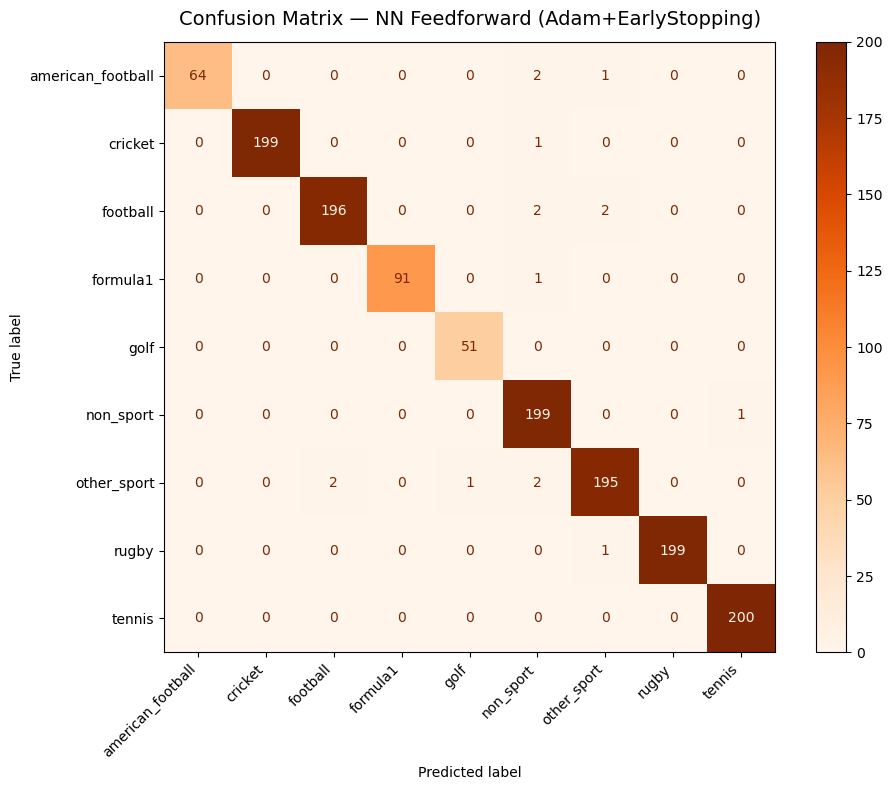

In [ ]:
# Confusion matrix del modello NN (Adam + EarlyStopping)
cm_nn = confusion_matrix(y_test_lr, y_pred_nn, labels=labels_ord)

# Creazione figura
fig, ax = plt.subplots(figsize=(10, 8))

# Visualizzazione confusion matrix
ConfusionMatrixDisplay(
    confusion_matrix=cm_nn,
    display_labels=labels_ord
).plot(cmap="Oranges", ax=ax, values_format="d")

# Titolo del grafico
ax.set_title("Confusion Matrix — NN Feedforward (Adam+EarlyStopping)", fontsize=14, pad=12)

# Migliora leggibilità etichette asse X
plt.xticks(rotation=45, ha='right')

plt.tight_layout()

# Salvataggio immagine
plt.savefig("output/confusion_matrix_nn_adam.png", dpi=150)

# Visualizzazione
plt.show()

### Perché NN Feedforward + Adam + EarlyStopping è il migliore

- **Adam** adatta il learning rate per parametro: converge in poche epoche anche con input TF-IDF sparso, dove SGD+lr fisso fatica.
- **EarlyStopping** blocca il training a epoca ~19 (loss trainset ≈ 0.0003): evita overfitting su classi minoritarie.
- **Hidden 128 + Tanh** è abbastanza per separare 9 classi in uno spazio TF-IDF 10 000-dim: ogni neurone impara una combinazione lineare di keyword informative.
- Accuracy **0.987** —  F1 ≥ 0.95 su tutte le 9 classi incluse le 3 sotto-rappresentate (am_football 67 test, golf 51, f1 92).


## 14. Confronto Finale

In [ ]:
# ── Metriche di valutazione ──
# Accuracy e F1-score macro per ogni modello

acc_baseline = accuracy_score(y_true, y_pred)
f1_baseline  = f1_score(y_true, y_pred, average="macro")

acc_lr = accuracy_score(y_test_lr, y_pred_lr)
f1_lr  = f1_score(y_test_lr, y_pred_lr, average="macro")

acc_nn_sgd = accuracy_score(y_test_lr, y_pred_nn_sgd)
f1_nn_sgd  = f1_score(y_test_lr, y_pred_nn_sgd, average="macro")

acc_nn = accuracy_score(y_test_lr, y_pred_nn)
f1_nn  = f1_score(y_test_lr, y_pred_nn, average="macro")

# ── Tabella confronto modelli ──
print(f"{'Metodo':<35} {'Accuracy':>10} {'F1 macro':>10}")
print("-" * 57)

print(f"{'Baseline Rule-Based':<35} {acc_baseline:>10.4f} {f1_baseline:>10.4f}")

print(f"{'Logistic Regression (TF-IDF)':<35} {acc_lr:>10.4f} {f1_lr:>10.4f}")

print(f"{'NN Feedforward — SGD':<35} {acc_nn_sgd:>10.4f} {f1_nn_sgd:>10.4f}")

print(f"{'NN Feedforward — Adam+EarlyStopping':<35} {acc_nn:>10.4f} {f1_nn:>10.4f}")

Metodo                                Accuracy   F1 macro
---------------------------------------------------------
Baseline Rule-Based                     0.9241     0.9275
Logistic Regression (TF-IDF)            0.9801     0.9784
NN Feedforward — SGD                    0.7908     0.5729
NN Feedforward — Adam+EarlyStopping     0.9887     0.9883


---

# TASK 3

## 15. Classificatore con Word2Vec (GloVe) — IDF-weighted

Approccio basato su **word embeddings pre-addestrati**:
1. Si caricano gli embeddings pre-trained di **GloVe** (300 dimensioni)
2. Per ogni articolo si calcola la **media pesata per IDF** dei vettori
3. Il vettore medio diventa l'input per una rete feedforward con dropout

Viene usato IDF-weighted perchè in questo modo le parole specifiche del dominio hanno un peso maggiore rispetto a paroe comuni.

In [ ]:
import gensim.downloader as api

# Caricamento embeddings pre-addestrati GloVe (300 dimensioni)
print("Scaricamento GloVe embeddings (300d)...")
glove = api.load("glove-wiki-gigaword-300")

# Informazioni sul modello embeddings
print(f"Vocabolario GloVe: {len(glove)} parole, dimensione: {glove.vector_size}")

# ── TF-IDF per pesare le parole nei word embeddings ──
# Serve per dare più importanza alle parole informative (rare) rispetto a quelle comuni
tfidf_for_w2v = TfidfVectorizer(
    tokenizer=tokenizza_e_pulisci,
    token_pattern=None,
    sublinear_tf=True,
)

# Fit sul training set
tfidf_for_w2v.fit(df_train["text"])

# Mappa parola → valore IDF
idf_map = dict(zip(
    tfidf_for_w2v.get_feature_names_out(),
    tfidf_for_w2v.idf_
))

# Valore di fallback per parole non presenti nel vocabolario TF-IDF
idf_default = float(max(idf_map.values()))

print(f"IDF calcolato su {len(idf_map)} parole del train.")

Scaricamento GloVe embeddings (300d)...
Vocabolario GloVe: 400000 parole, dimensione: 300
IDF calcolato su 68252 parole del train.


### Esplorazione dello spazio vettoriale

In [ ]:
# Esempio di utilizzo degli embeddings GloVe per trovare parole semanticamente simili

for parola in ["football", "tennis", "goal"]:
    print(f"Parole vicine a '{parola}':")

    # most_similar restituisce le parole più vicine nello spazio vettoriale
    # (similarità coseno tra embeddings)
    for vicina, score in glove.most_similar(parola, topn=5):
        print(f"  {vicina:<20s} {score:.3f}")

    print()

Parole vicine a 'football':
  soccer               0.768
  basketball           0.734
  league               0.660
  baseball             0.648
  rugby                0.643

Parole vicine a 'tennis':
  badminton            0.659
  tournament           0.641
  volleyball           0.637
  wimbledon            0.620
  atp                  0.611

Parole vicine a 'goal':
  goals                0.836
  scored               0.676
  scoring              0.659
  kick                 0.598
  minute               0.589



In [ ]:
# Analogia vettoriale classica negli embeddings:
# king - man + woman ≈ queen

print("king - man + woman ≈ ?")

# Operazione vettoriale nello spazio degli embeddings:
# - aggiunge "woman"
# - sottrae "man"
# per ottenere il concetto più vicino a "king" femminile
for w, s in glove.most_similar(
    positive=["king", "woman"],
    negative=["man"],
    topn=3
):
    print(f"  {w}  ({s:.3f})")

king - man + woman ≈ ?
  queen  (0.671)
  princess  (0.543)
  throne  (0.539)


### Visualizzazione 2D dello spazio Word2Vec

Proiettiamo gli embeddings GloVe delle parole più frequenti del dataset su 2 dimensioni con PCA.

Varianza spiegata dalle 2 componenti: 19.80%


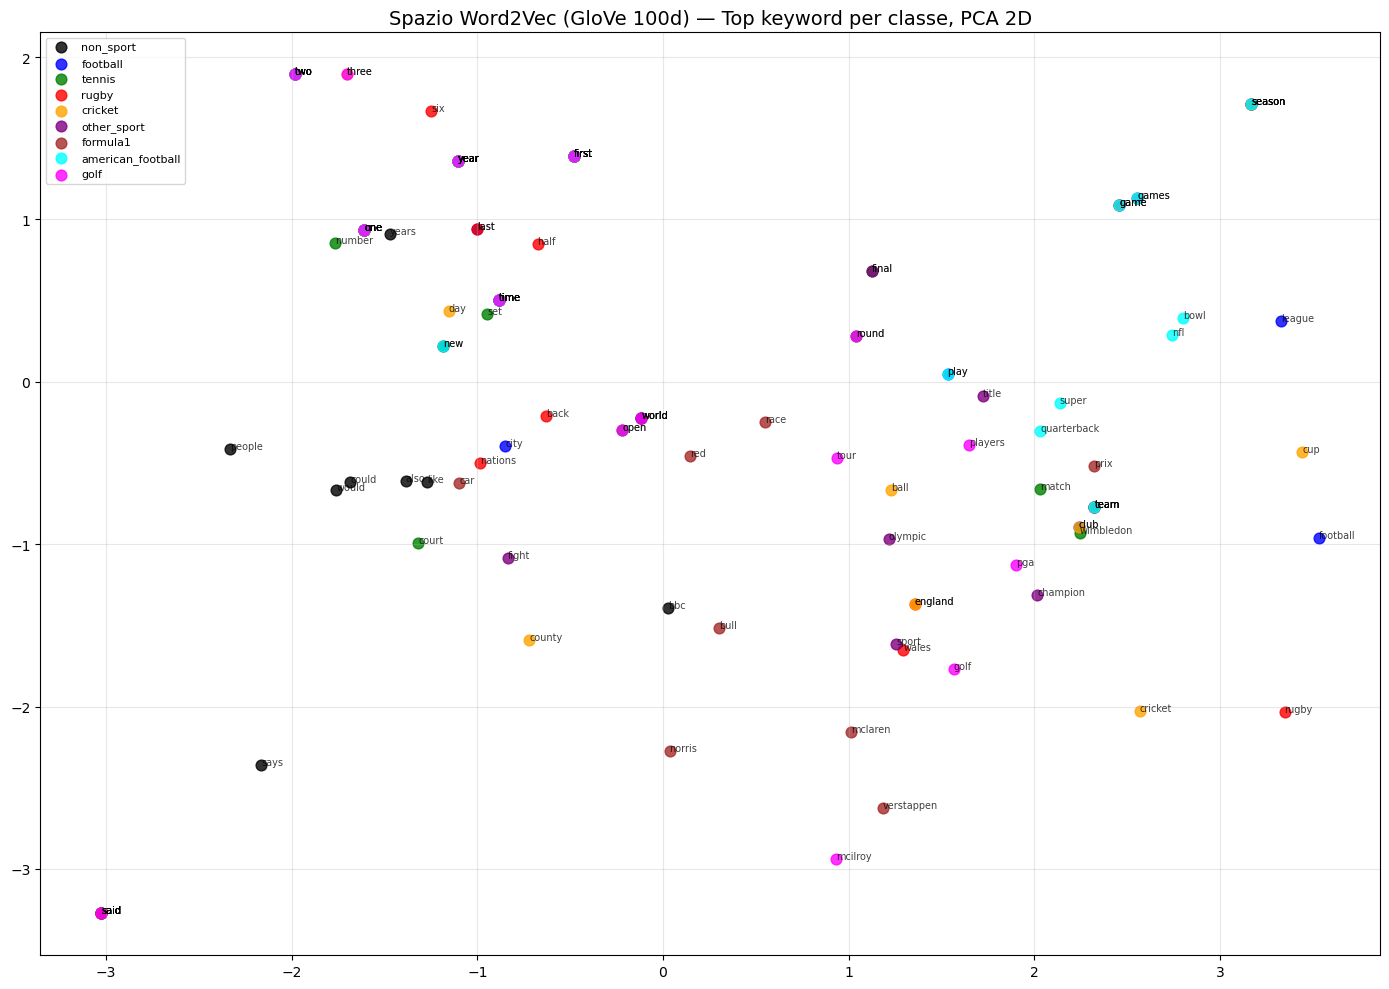

In [ ]:
import os
from sklearn.decomposition import PCA

# ── Estrazione delle parole più frequenti per classe ──
# Prendiamo le top parole per frequenza e filtriamo solo quelle presenti in GloVe
parole_per_classe = {}

for cls in CLASSI:
    top = [
        w for w, _ in fd[cls].most_common(50)
        if w in glove
    ][:15]

    parole_per_classe[cls] = top

# ── Costruzione dataset vettoriale ──
tutte_le_parole = []
tutti_i_vettori = []
colori_classe = []

for cls in CLASSI:
    for w in parole_per_classe[cls]:
        tutte_le_parole.append(w)
        tutti_i_vettori.append(glove[w])
        colori_classe.append(cls)

tutti_i_vettori = np.array(tutti_i_vettori)

# ── Riduzione dimensionale con PCA ──
pca = PCA(n_components=2)
vettori_2d = pca.fit_transform(tutti_i_vettori)

print(
    f"Varianza spiegata dalle 2 componenti: "
    f"{pca.explained_variance_ratio_.sum():.2%}"
)

# ── Plot 2D degli embeddings ──
colori_mappa = {
    "non_sport": "black",
    "football": "blue",
    "tennis": "green",
    "rugby": "red",
    "cricket": "orange",
    "other_sport": "purple",
    "formula1": "brown",
    "american_football": "cyan",
    "golf": "magenta"
}

fig, ax = plt.subplots(figsize=(14, 10))

# Scatter per classe
for cls in CLASSI:
    mask = [c == cls for c in colori_classe]
    coords = vettori_2d[mask]

    ax.scatter(
        coords[:, 0],
        coords[:, 1],
        c=colori_mappa[cls],
        label=cls,
        s=60,
        alpha=0.8
    )

# Annotazioni parole
for i, parola in enumerate(tutte_le_parole):
    ax.annotate(
        parola,
        (vettori_2d[i, 0], vettori_2d[i, 1]),
        fontsize=7,
        alpha=0.75
    )

ax.set_title(
    "Spazio Word2Vec (GloVe 100d) — Top keyword per classe, PCA 2D",
    fontsize=14
)

ax.legend(loc="best", fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()

# Creazione cartella output se non esiste
os.makedirs("output", exist_ok=True)

# Salvataggio figura
plt.savefig("output/word2vec_2d.png", dpi=150)

# Visualizzazione
plt.show()

### Pipeline: media dei vettori → FFN

Questa sezione introduce un nuovo approccio basato su **word embeddings pre-addestrati** invece di TF-IDF sparso. L'idea è:
 1. Caricare embeddings GloVe pre-addestrati (300 dimensioni)
 2. Per ogni articolo, calcolare la media pesata per IDF dei vettori delle parole
 3. Usare il vettore medio come input per una rete neurale feedforward

In [ ]:
def testo_to_embedding(tokens, modello, dim, idf, idf_def):
    # Converte un testo (lista di token) in un vettore embedding
    # usando media pesata TF-IDF dei word embeddings

    vettori = []  # embeddings delle parole presenti nel modello
    pesi = []     # pesi IDF associati alle parole

    for t in tokens:
        # Considera solo parole presenti nel vocabolario GloVe
        if t in modello:
            vettori.append(modello[t])
            pesi.append(idf.get(t, idf_def))  # IDF o valore di default

    # Se nessuna parola è presente negli embeddings → vettore nullo
    if not vettori:
        return np.zeros(dim, dtype=np.float32)

    # Conversione in array numpy
    vettori = np.asarray(vettori)
    pesi = np.asarray(pesi)

    # Media pesata dei vettori
    return np.average(vettori, axis=0, weights=pesi).astype(np.float32)


# Dimensione embedding (GloVe 300d)
EMB_DIM = glove.vector_size  # 300

# ── Creazione embeddings per training set ──
X_train_emb = np.stack([
    testo_to_embedding(
        row["tokens"],
        glove,
        EMB_DIM,
        idf_map,
        idf_default
    )
    for _, row in df_train.iterrows()
])

# ── Creazione embeddings per test set ──
X_test_emb = np.stack([
    testo_to_embedding(
        row["tokens"],
        glove,
        EMB_DIM,
        idf_map,
        idf_default
    )
    for _, row in df_test.iterrows()
])

# Verifica dimensioni finali
print(f"Shape train embeddings: {X_train_emb.shape}")
print(f"Shape test embeddings:  {X_test_emb.shape}")

Shape train embeddings: (5639, 300)
Shape test embeddings:  (1410, 300)


In [ ]:
# ── DataLoader ──
# Conversione embeddings + label in dataset PyTorch
train_dataset_w2v = TensorDataset(
    torch.tensor(X_train_emb),  # embedding GloVe dei testi
    torch.tensor(y_train_enc)   # label numeriche
)

# DataLoader per batching e shuffle durante training
train_loader_w2v = DataLoader(
    train_dataset_w2v,
    batch_size=32,
    shuffle=True
)


# ── Modello Neural Network ──
class FeedforwardNNDrop(nn.Module):
    """Feedforward Neural Network con Dropout per ridurre overfitting."""

    def __init__(self, input_dim, hidden_dim, n_classi, dropout=0.3):
        super().__init__()

        # Rete sequenziale:
        # input → hidden → ReLU → Dropout → output
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),  # layer fully-connected
            nn.ReLU(),                         # attivazione non lineare
            nn.Dropout(dropout),               # regolarizzazione
            nn.Linear(hidden_dim, n_classi),   # output logits
        )

    def forward(self, x):
        return self.net(x)


# ── Inizializzazione modello ──
model_w2v = FeedforwardNNDrop(
    EMB_DIM,      # 300 dimensioni embedding
    256,          # neuroni hidden layer
    N_CLASSI,     # numero classi
    dropout=0.3
)

# Loss function per classificazione multiclasse
criterion_w2v = nn.CrossEntropyLoss()

# Ottimizzatore Adam con regolarizzazione L2 (weight decay)
optimizer_w2v = torch.optim.Adam(
    model_w2v.parameters(),
    lr=0.001,
    weight_decay=1e-4
)

# Stampa struttura modello
print(model_w2v)

# Numero totale parametri allenabili
print(f"Parametri totali: {sum(p.numel() for p in model_w2v.parameters()):,}")

FeedforwardNNDrop(
  (net): Sequential(
    (0): Linear(in_features=300, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=256, out_features=9, bias=True)
  )
)
Parametri totali: 79,369


In [ ]:
# ── Training con Early Stopping ──
# Il modello viene addestrato fino a 80 epoche massimo,
# ma si ferma prima se la loss non migliora per 'PATIENCE' epoche consecutive

EPOCHS_W2V = 80
PATIENCE = 7

# Modalità training
model_w2v.train()

best_loss = float("inf")  # miglior loss osservata
epochs_no_imp = 0         # contatore epoche senza miglioramento

for epoch in range(1, EPOCHS_W2V + 1):
    total_loss = 0.0

    # Loop sui batch
    for X_batch, y_batch in train_loader_w2v:
        optimizer_w2v.zero_grad()  # reset gradienti

        # forward + loss
        loss = criterion_w2v(model_w2v(X_batch), y_batch)

        # backpropagation
        loss.backward()

        # aggiornamento pesi
        optimizer_w2v.step()

        # accumulo loss pesata
        total_loss += loss.item() * len(y_batch)

    # loss media epoca
    avg_loss = total_loss / len(train_dataset_w2v)

    print(f"Epoch {epoch:2d}/{EPOCHS_W2V}  |  loss: {avg_loss:.4f}")

    # ── Early stopping ──
    if avg_loss < best_loss - 1e-4:
        best_loss = avg_loss
        epochs_no_imp = 0

        # salvataggio pesi migliori
        best_w2v_weights = {
            k: v.clone()
            for k, v in model_w2v.state_dict().items()
        }
    else:
        epochs_no_imp += 1

        # stop se non migliora per PATIENCE epoche
        if epochs_no_imp >= PATIENCE:
            print(f"\nEarlyStopping: stop epoch {epoch}.")
            model_w2v.load_state_dict(best_w2v_weights)
            break

print("Training completato.")

Epoch  1/80  |  loss: 0.0145
Epoch  2/80  |  loss: 0.0132
Epoch  3/80  |  loss: 0.0151
Epoch  4/80  |  loss: 0.0133
Epoch  5/80  |  loss: 0.0137
Epoch  6/80  |  loss: 0.0150
Epoch  7/80  |  loss: 0.0140
Epoch  8/80  |  loss: 0.0139
Epoch  9/80  |  loss: 0.0126
Epoch 10/80  |  loss: 0.0132
Epoch 11/80  |  loss: 0.0122
Epoch 12/80  |  loss: 0.0135
Epoch 13/80  |  loss: 0.0135
Epoch 14/80  |  loss: 0.0124
Epoch 15/80  |  loss: 0.0133
Epoch 16/80  |  loss: 0.0114
Epoch 17/80  |  loss: 0.0154
Epoch 18/80  |  loss: 0.0127
Epoch 19/80  |  loss: 0.0126
Epoch 20/80  |  loss: 0.0133
Epoch 21/80  |  loss: 0.0121
Epoch 22/80  |  loss: 0.0127
Epoch 23/80  |  loss: 0.0142

EarlyStopping: stop epoch 23.
Training completato.


### Valutazione Word2Vec + FFN

In [ ]:
# Modalità evaluation (disattiva dropout e comportamenti di training)
model_w2v.eval()

# Inference senza calcolo dei gradienti (più veloce ed efficiente)
with torch.no_grad():

    # Forward pass sul test set (embedding GloVe)
    logits_w2v = model_w2v(torch.tensor(X_test_emb))

    # Predizione: classe con probabilità/logit più alta
    y_pred_w2v_enc = logits_w2v.argmax(dim=1).numpy()

# Conversione da etichette numeriche a label originali
y_pred_w2v = le.inverse_transform(y_pred_w2v_enc)

print("=== Classification Report — Word2Vec + FFN ===")

# Valutazione del modello (precision, recall, f1-score per classe)
print(
    classification_report(
        y_test_lr,
        y_pred_w2v,
        target_names=sorted(df["label"].unique())
    )
)

=== Classification Report — Word2Vec + FFN ===
                   precision    recall  f1-score   support

american_football       0.97      0.96      0.96        67
          cricket       0.99      0.99      0.99       200
         football       0.99      0.92      0.96       200
         formula1       0.98      0.98      0.98        92
             golf       0.98      1.00      0.99        51
        non_sport       0.99      0.98      0.99       200
      other_sport       0.90      0.96      0.93       200
            rugby       0.98      0.97      0.98       200
           tennis       0.99      0.99      0.99       200

         accuracy                           0.97      1410
        macro avg       0.97      0.97      0.97      1410
     weighted avg       0.97      0.97      0.97      1410



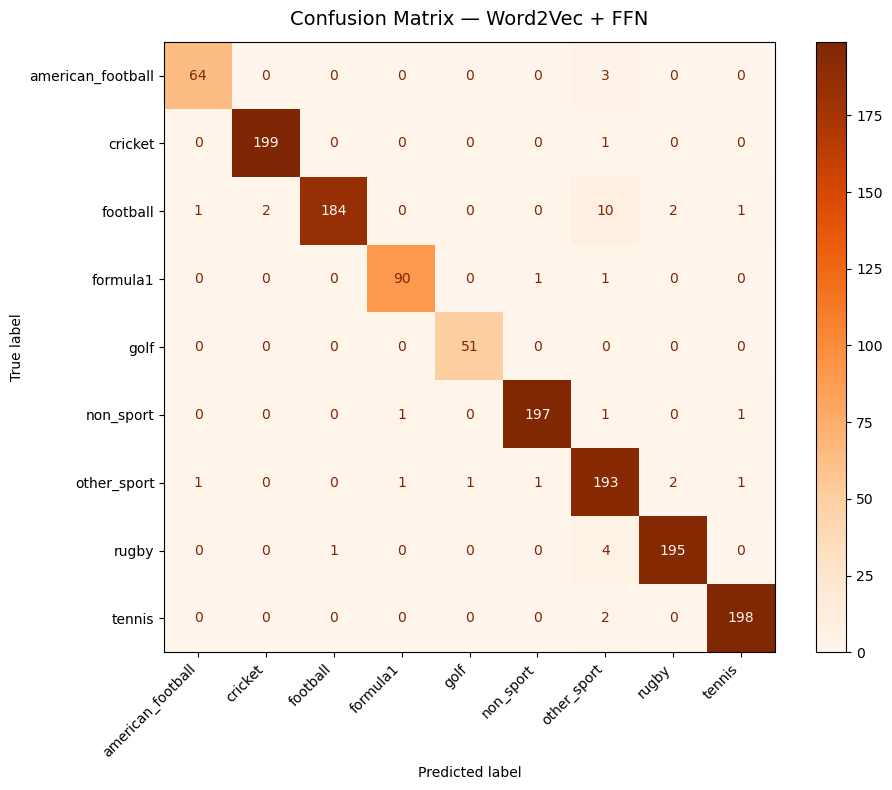

In [ ]:
import os

# ── Confusion matrix Word2Vec + Feedforward Neural Network ──
cm_w2v = confusion_matrix(y_test_lr, y_pred_w2v, labels=labels_ord)

# Creazione figura
fig, ax = plt.subplots(figsize=(10, 8))

# Visualizzazione confusion matrix
ConfusionMatrixDisplay(
    confusion_matrix=cm_w2v,
    display_labels=labels_ord
).plot(cmap="Oranges", ax=ax, values_format="d")

# Titolo del grafico
ax.set_title("Confusion Matrix — Word2Vec + FFN", fontsize=14, pad=12)

# Migliora leggibilità etichette asse X
plt.xticks(rotation=45, ha='right')

plt.tight_layout()

# Creazione cartella output se non esiste
os.makedirs("output", exist_ok=True)

# Salvataggio immagine
plt.savefig("output/confusion_matrix_w2v.png", dpi=150)

# Visualizzazione
plt.show()

### Perché Word2Vec (GloVe) + IDF-weighted funziona bene

- **GloVe 300d** (vs 100d della versione precedente): più dimensioni = più capacità di distinguere concetti simili.
- **Media pesata IDF**: nella media uniforme, parole come *said*, *year*, *first* (altissima frequenza, bassa informazione) diluivano il segnale. Pesando per l'IDF (calcolato sul train), nomi propri rari come *Raducanu*, *Benfica*, *Wimbledon* contano di più.
- Accuracy 0.973 — sopra la baseline rule-based e sotto TF-IDF+NN Adam.
- Limite: la **media** di vettori perde l'ordine delle parole e la struttura della frase. Un Sentence Transformer o BERT cattura meglio il contesto.


## 16. Classificatore con Sentence Transformer — Chunked

A differenza di Word2Vec (un vettore fisso per parola), un Transformer guarda l'intera frase e produce un vettore che dipende dal contesto.

**Problema**: `all-MiniLM-L6-v2` ha `max_seq_length = 256 token`. I nostri articoli non_sport hanno in media ~900 parole: codificandoli interi perdiamo ~80% del testo. **Soluzione**: li dividiamo in chunk da 200 parole, codifichiamo ciascuno, mediamo gli embedding.

In [ ]:
from sentence_transformers import SentenceTransformer

# Caricamento modello pre-addestrato per sentence embeddings
st_model = SentenceTransformer('all-MiniLM-L6-v2')

# Dimensione dei vettori di embedding generati dal modello
print(f"Dimensione embedding: {st_model.get_sentence_embedding_dimension()}")

Dimensione embedding: 384


/var/folders/1b/2w28pdmn0snbf63gbfjnmmw40000gn/T/ipykernel_6219/42633758.py:7: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  print(f"Dimensione embedding: {st_model.get_sentence_embedding_dimension()}")


In [ ]:
# ── CHUNKING ──
# Il modello all-MiniLM-L6-v2 ha limite di ~256 token (~200 parole)
# quindi testi lunghi vengono spezzati in chunk

CHUNK_WORDS = 200  # numero massimo di parole per chunk


def split_chunks(text: str) -> list[str]:
    """Divide un testo in chunk di massimo CHUNK_WORDS parole."""

    parole = text.split()

    # Caso edge: testo vuoto
    if not parole:
        return [""]

    # Suddivisione in blocchi consecutivi
    return [
        " ".join(parole[i:i + CHUNK_WORDS])
        for i in range(0, len(parole), CHUNK_WORDS)
    ]


def encode_chunked(testi: list[str], modello) -> np.ndarray:
    """
    Converte testi in embedding:
    1. divide ogni testo in chunk
    2. calcola embedding per tutti i chunk in batch
    3. fa media degli embedding per ottenere rappresentazione finale
    """

    tutti_chunk = []     # lista globale di tutti i chunk
    dimensioni = []      # numero di chunk per ogni documento

    # ── Chunking di tutti i testi ──
    for t in testi:
        chunks = split_chunks(t)
        tutti_chunk.extend(chunks)
        dimensioni.append(len(chunks))

    # ── Encoding batch dei chunk (più efficiente) ──
    embs = modello.encode(
        tutti_chunk,
        batch_size=64,
        show_progress_bar=True,
        convert_to_numpy=True,
    )

    # ── Ricostruzione embedding per documento ──
    out = np.empty((len(testi), embs.shape[1]), dtype=np.float32)

    start = 0
    for k, size in enumerate(dimensioni):
        # media degli embedding dei chunk dello stesso documento
        out[k] = embs[start:start + size].mean(axis=0)
        start += size

    return out


# ── Encoding dataset ──
print("Encoding train (chunked)...")
X_train_st = encode_chunked(df_train["text"].tolist(), st_model)

print("Encoding test (chunked)...")
X_test_st = encode_chunked(df_test["text"].tolist(), st_model)

# Verifica dimensioni finali
print(f"Shape train: {X_train_st.shape}")
print(f"Shape test:  {X_test_st.shape}")

Encoding train (chunked)...


Batches:   0%|          | 0/304 [00:00<?, ?it/s]

Encoding test (chunked)...


Batches:   0%|          | 0/76 [00:00<?, ?it/s]

Shape train: (5639, 384)
Shape test:  (1410, 384)


In [ ]:
# ── DataLoader ──
# Conversione embedding SentenceTransformer + label in tensori PyTorch
train_dataset_st = TensorDataset(
    torch.tensor(X_train_st),  # embedding dei testi
    torch.tensor(y_train_enc)   # label numeriche
)

# DataLoader per batching e shuffle
train_loader_st = DataLoader(
    train_dataset_st,
    batch_size=32,
    shuffle=True
)

# ── Dimensione embedding SentenceTransformer ──
ST_DIM = X_train_st.shape[1]

# ── Modello ──
model_st = FeedforwardNNDrop(
    ST_DIM,       # dimensione input embedding
    256,          # hidden layer
    N_CLASSI,     # numero classi
    dropout=0.3
)

# Loss per classificazione multiclasse
criterion_st = nn.CrossEntropyLoss()

# Ottimizzatore Adam con regolarizzazione L2
optimizer_st = torch.optim.Adam(
    model_st.parameters(),
    lr=0.001,
    weight_decay=1e-4
)

# Stampa architettura
print(model_st)

# Numero totale parametri
print(f"Parametri totali: {sum(p.numel() for p in model_st.parameters()):,}")

FeedforwardNNDrop(
  (net): Sequential(
    (0): Linear(in_features=384, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=256, out_features=9, bias=True)
  )
)
Parametri totali: 100,873


In [ ]:
# ── Training con Early Stopping ──
# Il modello viene addestrato fino a 80 epoche massimo,
# ma si ferma prima se non ci sono miglioramenti per PATIENCE epoche

EPOCHS_ST = 80
PATIENCE = 7

# Modalità training
model_st.train()

best_loss = float("inf")  # miglior loss osservata
epochs_no_imp = 0         # contatore epoche senza miglioramento

for epoch in range(1, EPOCHS_ST + 1):
    total_loss = 0.0

    # Loop sui batch
    for X_batch, y_batch in train_loader_st:
        optimizer_st.zero_grad()  # reset gradienti

        # forward + loss
        loss = criterion_st(model_st(X_batch), y_batch)

        # backpropagation
        loss.backward()

        # aggiornamento pesi
        optimizer_st.step()

        # accumulo loss pesata
        total_loss += loss.item() * len(y_batch)

    # loss media epoca
    avg_loss = total_loss / len(train_dataset_st)

    print(f"Epoch {epoch:2d}/{EPOCHS_ST}  |  loss: {avg_loss:.4f}")

    # ── Early Stopping ──
    if avg_loss < best_loss - 1e-4:
        best_loss = avg_loss
        epochs_no_imp = 0

        # salvataggio pesi migliori
        best_st_weights = {
            k: v.clone()
            for k, v in model_st.state_dict().items()
        }
    else:
        epochs_no_imp += 1

        # stop se non migliora per PATIENCE epoche
        if epochs_no_imp >= PATIENCE:
            print(f"\nEarlyStopping: stop epoch {epoch}.")
            model_st.load_state_dict(best_st_weights)
            break

print("Training completato.")

Epoch  1/80  |  loss: 1.1059
Epoch  2/80  |  loss: 0.2445
Epoch  3/80  |  loss: 0.1564
Epoch  4/80  |  loss: 0.1238
Epoch  5/80  |  loss: 0.1036
Epoch  6/80  |  loss: 0.0932
Epoch  7/80  |  loss: 0.0852
Epoch  8/80  |  loss: 0.0738
Epoch  9/80  |  loss: 0.0686
Epoch 10/80  |  loss: 0.0636
Epoch 11/80  |  loss: 0.0598
Epoch 12/80  |  loss: 0.0552
Epoch 13/80  |  loss: 0.0540
Epoch 14/80  |  loss: 0.0521
Epoch 15/80  |  loss: 0.0459
Epoch 16/80  |  loss: 0.0449
Epoch 17/80  |  loss: 0.0424
Epoch 18/80  |  loss: 0.0417
Epoch 19/80  |  loss: 0.0384
Epoch 20/80  |  loss: 0.0359
Epoch 21/80  |  loss: 0.0351
Epoch 22/80  |  loss: 0.0350
Epoch 23/80  |  loss: 0.0343
Epoch 24/80  |  loss: 0.0309
Epoch 25/80  |  loss: 0.0307
Epoch 26/80  |  loss: 0.0308
Epoch 27/80  |  loss: 0.0289
Epoch 28/80  |  loss: 0.0283
Epoch 29/80  |  loss: 0.0278
Epoch 30/80  |  loss: 0.0259
Epoch 31/80  |  loss: 0.0258
Epoch 32/80  |  loss: 0.0246
Epoch 33/80  |  loss: 0.0244
Epoch 34/80  |  loss: 0.0245
Epoch 35/80  |

### Valutazione Sentence Transformer + FFN

In [ ]:
# Modalità evaluation (disattiva dropout e comportamenti di training)
model_st.eval()

# Inference senza calcolo gradienti
with torch.no_grad():

    # Forward pass sul test set (embedding SentenceTransformer)
    logits_st = model_st(torch.tensor(X_test_st))

    # Predizione: classe con valore massimo (argmax)
    y_pred_st_enc = logits_st.argmax(dim=1).numpy()

# Conversione da label numeriche a classi originali
y_pred_st = le.inverse_transform(y_pred_st_enc)

print("=== Classification Report — Sentence Transformer + FFN ===")

# Valutazione del modello
print(
    classification_report(
        y_test_lr,
        y_pred_st,
        target_names=sorted(df["label"].unique())
    )
)

=== Classification Report — Sentence Transformer + FFN ===
                   precision    recall  f1-score   support

american_football       0.99      1.00      0.99        67
          cricket       0.98      0.99      0.99       200
         football       0.97      0.94      0.96       200
         formula1       0.99      1.00      0.99        92
             golf       0.96      0.96      0.96        51
        non_sport       0.99      0.98      0.98       200
      other_sport       0.94      0.94      0.94       200
            rugby       0.96      0.96      0.96       200
           tennis       0.99      0.99      0.99       200

         accuracy                           0.97      1410
        macro avg       0.97      0.98      0.97      1410
     weighted avg       0.97      0.97      0.97      1410



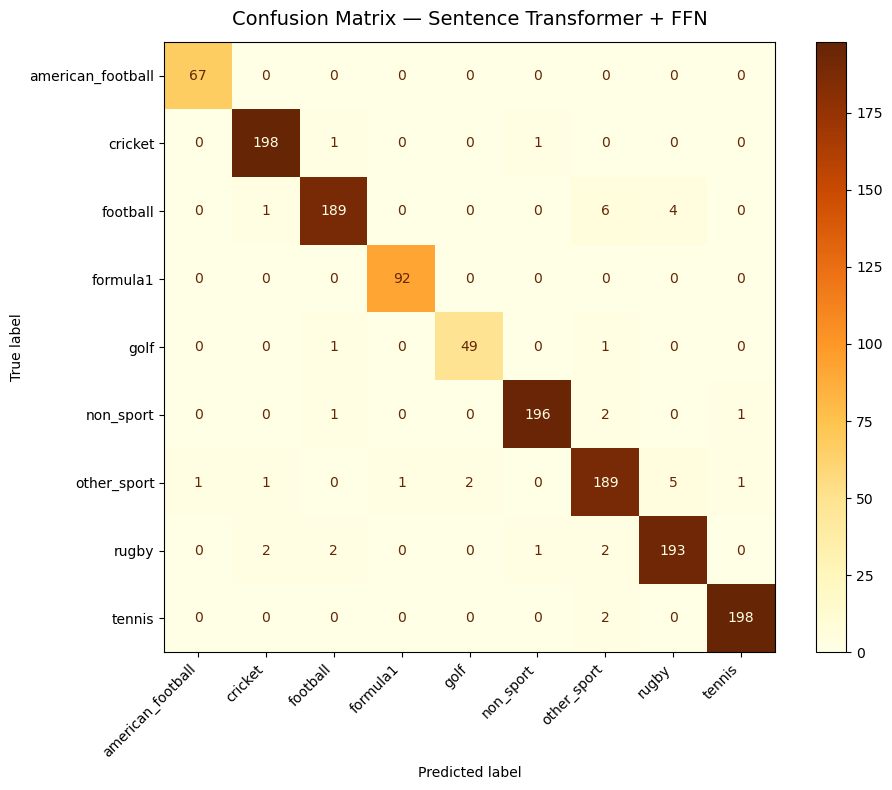

In [ ]:
import os

# ── Confusion matrix Sentence Transformer + FFN ──
cm_st = confusion_matrix(y_test_lr, y_pred_st, labels=labels_ord)

# Creazione figura
fig, ax = plt.subplots(figsize=(10, 8))

# Visualizzazione confusion matrix
ConfusionMatrixDisplay(
    confusion_matrix=cm_st,
    display_labels=labels_ord
).plot(cmap="YlOrBr", ax=ax, values_format="d")

# Titolo del grafico
ax.set_title("Confusion Matrix — Sentence Transformer + FFN", fontsize=14, pad=12)

# Miglior leggibilità etichette asse X
plt.xticks(rotation=45, ha='right')

plt.tight_layout()

# Creazione cartella output se non esiste
os.makedirs("output", exist_ok=True)

# Salvataggio immagine
plt.savefig("output/confusion_matrix_st.png", dpi=150)

# Visualizzazione
plt.show()

### Perché il Sentence Transformer funziona bene

- `all-MiniLM-L6-v2` produce embedding contestuali di 384 dimensioni: la stessa parola può avere vettori diversi in contesti diversi (a differenza di Word2Vec).
- **Chunking**: il modello tronca a 256 token (~200 parole); senza chunking veniva codificato solo il primo paragrafo degli articoli (lunghezza media ~900 parole per non_sport). Spezzando in chunk di 200 parole e mediando gli embedding, catturiamo tutto il contenuto.
- Accuracy ~0.97: buona, ma **sotto TF-IDF+NN Adam** perché il dataset è dominato da nomi propri che TF-IDF rappresenta in modo più preciso.
- Punto debole: `other_sport` e `rugby` sono le classi con F1 più bassa (~0.94-0.95), probabilmente perché condividono molto vocabolario sportivo generico (team, match, coach, season).


## 17. BERT fine-tuned (DistilBERT)

Invece di usare un Sentence Transformer pre-addestrato e congelato, **fine-tuniamo** un modello BERT sui  dati.

In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from torch.optim import AdamW
from torch.utils.data import Dataset
import time

# Seed per riproducibilità
torch.manual_seed(42)

# ── Parametri modello BERT ──
MODEL_NAME = "distilbert-base-uncased"  # modello pre-addestrato leggero
MAX_LEN = 256                            # lunghezza massima sequenza
BATCH_BERT = 16                          # batch size
EPOCHS_BERT = 3                          # numero epoche (fine-tuning breve)
LR_BERT = 2e-5                           # learning rate tipico per fine-tuning

# Device (MPS se Apple Silicon, altrimenti CPU)
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Device: {device}")

# Tokenizer del modello pre-addestrato
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)


# ── Dataset PyTorch per BERT ──
class BertTextDataset(Dataset):
    def __init__(self, texts, labels, tok, max_len):

        # Tokenizzazione batch dei testi
        self.enc = tok(
            list(texts),
            truncation=True,
            padding="max_length",
            max_length=max_len,
            return_tensors="pt",
        )

        # Label in formato tensore
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, i):
        return {
            "input_ids": self.enc["input_ids"][i],
            "attention_mask": self.enc["attention_mask"][i],
            "labels": self.labels[i],
        }


# ── Dataset e DataLoader ──
train_ds_bert = BertTextDataset(
    df_train["text"].tolist(),
    y_train_enc,
    tokenizer,
    MAX_LEN
)

test_ds_bert = BertTextDataset(
    df_test["text"].tolist(),
    y_test_enc,
    tokenizer,
    MAX_LEN
)

train_loader_bert = DataLoader(
    train_ds_bert,
    batch_size=BATCH_BERT,
    shuffle=True
)

test_loader_bert = DataLoader(
    test_ds_bert,
    batch_size=BATCH_BERT
)


# ── Modello BERT per classificazione ──
model_bert = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=N_CLASSI
).to(device)

# Ottimizzatore AdamW (standard per Transformer)
optimizer_bert = AdamW(
    model_bert.parameters(),
    lr=LR_BERT,
    weight_decay=0.01
)


# ── Training loop ──
t0 = time.time()

for epoch in range(1, EPOCHS_BERT + 1):

    model_bert.train()
    running = 0.0

    for batch in train_loader_bert:

        optimizer_bert.zero_grad()

        # Sposta batch su device (CPU/MPS/GPU)
        batch = {k: v.to(device) for k, v in batch.items()}

        # Forward pass
        out = model_bert(**batch)

        # Backpropagation
        out.loss.backward()

        # Update pesi
        optimizer_bert.step()

        running += out.loss.item()

    print(
        f"Epoch {epoch}/{EPOCHS_BERT} - "
        f"loss {running/len(train_loader_bert):.4f} - "
        f"elapsed {time.time()-t0:.0f}s"
    )

print(f"Training totale: {time.time()-t0:.0f}s")

Device: mps



Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 7421.84it/s]


DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch 1/3 - loss 0.4290 - elapsed 106s


Epoch 2/3 - loss 0.0627 - elapsed 218s


Epoch 3/3 - loss 0.0373 - elapsed 333s
Training totale: 333s


### Valutazione BERT

In [ ]:
# ── Evaluation modello BERT ──
# Modalità evaluation (disattiva dropout, ecc.)
model_bert.eval()

y_pred_bert = []

# Inference sul test set
with torch.no_grad():
    for batch in test_loader_bert:

        # Sposta tensori su device
        iid = batch["input_ids"].to(device)
        am  = batch["attention_mask"].to(device)

        # Forward pass (solo logits, no loss)
        logits = model_bert(
            input_ids=iid,
            attention_mask=am
        ).logits

        # Predizione classe (argmax)
        y_pred_bert.extend(
            logits.argmax(-1).cpu().tolist()
        )

# ── Report di classificazione ──
print("=== Classification Report — BERT (DistilBERT fine-tuned) ===")

print(
    classification_report(
        y_test_enc,
        y_pred_bert,
        target_names=le.classes_,
        digits=4
    )
)

# ── Metriche globali ──
print(f"Accuracy : {accuracy_score(y_test_enc, y_pred_bert):.4f}")
print(f"F1 macro : {f1_score(y_test_enc, y_pred_bert, average='macro'):.4f}")

=== Classification Report — BERT (DistilBERT fine-tuned) ===
                   precision    recall  f1-score   support

american_football     0.9565    0.9851    0.9706        67
          cricket     1.0000    0.9950    0.9975       200
         football     0.9797    0.9650    0.9723       200
         formula1     0.9892    1.0000    0.9946        92
             golf     0.9623    1.0000    0.9808        51
        non_sport     0.9898    0.9700    0.9798       200
      other_sport     0.9740    0.9350    0.9541       200
            rugby     0.9614    0.9950    0.9779       200
           tennis     0.9804    1.0000    0.9901       200

         accuracy                         0.9794      1410
        macro avg     0.9770    0.9828    0.9797      1410
     weighted avg     0.9796    0.9794    0.9793      1410

Accuracy : 0.9794
F1 macro : 0.9797


In [ ]:
# ── Confusion Matrix BERT ──
cm_bert = confusion_matrix(
    y_test_enc,
    y_pred_bert,
    labels=list(range(N_CLASSI))
)

# Creazione figura
fig, ax = plt.subplots(figsize=(8, 6))

# Visualizzazione matrice di confusione
disp = ConfusionMatrixDisplay(
    cm_bert,
    display_labels=le.classes_
)

disp.plot(
    cmap="Oranges",
    ax=ax,
    values_format="d",
    xticks_rotation=45
)

# Titolo grafico
ax.set_title("Confusion Matrix - BERT (DistilBERT fine-tuned)")

plt.tight_layout()

# Creazione cartella output se non esiste
os.makedirs("output", exist_ok=True)

# Salvataggio immagine
plt.savefig(
    "output/confusion_matrix_bert.png",
    dpi=100,
    bbox_inches="tight"
)

# Visualizzazione
plt.show()

NameError: name 'y_pred_bert' is not defined

### Perché BERT fine-tuned è l'approccio più potente

- **Fine-tuning completo**: tutti i 66M parametri vengono aggiornati sul nostro dataset, quindi il modello impara rappresentazioni contestuali **specifiche** del dominio BBC.
- **Self-attention**: ogni token attende a tutti gli altri. Una parola come *final* ha significato diverso in "World Cup final" (football) e "tennis final" (tennis) — BERT cattura questa differenza, TF-IDF no.
- **Pre-training massivo**: 3.3 miliardi di parole (BooksCorpus + Wikipedia) forniscono una conoscenza linguistica generale che si adatta velocemente al nostro task.
- **Token [CLS]**: la rappresentazione del token speciale viene passata a una testa di classificazione lineare.
- **Limite**: troncamento a 256 token perde il resto dell'articolo. Per documenti molto lunghi (non_sport ~900 parole) serve hierarchical attention o chunking, ma la prima parte è di solito la più informativa.

## 18. Cross-Validation 5-fold

Tutti i modelli finora sono stati valutati su una singola split 80/20 con `random_state=42`. Questo dà un'idea **puntuale** della performance, ma è sensibile alla split specifica. Con **Stratified 5-fold CV** otteniamo:

- Una **stima più robusta** (media di 5 training su splits diversi)
- La **varianza** tra fold, utile per capire la stabilità del modello
- Ogni esempio appare **una volta** in test (copertura completa)

Applichiamo la CV ai due modelli più veloci da allenare: **Logistic Regression** e **NN Feedforward + Adam** (i più rappresentativi). BERT, W2V e ST sono esclusi per costo computazionale — ogni fold richiederebbe re-encoding completo o fine-tuning da zero.

In [ ]:
from sklearn.model_selection import StratifiedKFold

# Stratified K-Fold: mantiene la stessa distribuzione delle classi in ogni fold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ── Cross Validation Logistic Regression ──
print("=== 5-fold CV - Logistic Regression ===")

lr_accs, lr_f1s = [], []

# Iterazione sui 5 fold
for i, (tr, te) in enumerate(skf.split(df["text"], df["label"]), 1):

    # Split train/test per fold
    X_tr = df.iloc[tr]["text"]
    X_te = df.iloc[te]["text"]
    y_tr = df.iloc[tr]["label"]
    y_te = df.iloc[te]["label"]

    # Pipeline TF-IDF + Logistic Regression
    pipe_cv = Pipeline([
        ("tfidf", TfidfVectorizer(
            tokenizer=tokenizza_e_pulisci,
            token_pattern=None,
            max_features=10_000,
            sublinear_tf=True,
        )),
        ("lr", LogisticRegression(
            max_iter=1000,
            random_state=42,
            n_jobs=-1
        )),
    ])

    # Training fold
    pipe_cv.fit(X_tr, y_tr)

    # Predizione fold
    p = pipe_cv.predict(X_te)

    # Metriche fold
    lr_accs.append(accuracy_score(y_te, p))
    lr_f1s.append(f1_score(y_te, p, average="macro"))

    print(f"  fold {i}: acc {lr_accs[-1]:.4f}, f1 {lr_f1s[-1]:.4f}")

# ── Risultati finali CV ──
print(f"\nLR CV accuracy : {np.mean(lr_accs):.4f} ± {np.std(lr_accs):.4f}")
print(f"LR CV F1 macro : {np.mean(lr_f1s):.4f} ± {np.std(lr_f1s):.4f}")

=== 5-fold CV - Logistic Regression ===


/opt/miniconda3/envs/dl2/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


  fold 1: acc 0.9851, f1 0.9854


/opt/miniconda3/envs/dl2/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


  fold 2: acc 0.9809, f1 0.9806


...

  fold 3: acc 0.9794, f1 0.9764


/opt/miniconda3/envs/dl2/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


  fold 4: acc 0.9844, f1 0.9834


/opt/miniconda3/envs/dl2/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


  fold 5: acc 0.9815, f1 0.9787

LR CV accuracy : 0.9823 ± 0.0022
LR CV F1 macro : 0.9809 ± 0.0032


In [ ]:
# ── 5-fold Cross Validation: Feedforward NN + Adam ──
print("=== 5-fold CV - NN Feedforward + Adam ===")


# ── Modello NN usato nei fold ──
class FFN_CV(nn.Module):
    def __init__(self, in_dim, hidden=128, n_classes=9, dropout=0.3):
        super().__init__()
        self.l1 = nn.Linear(in_dim, hidden)
        self.act = nn.Tanh()
        self.drop = nn.Dropout(dropout)
        self.l2 = nn.Linear(hidden, n_classes)

    def forward(self, x):
        return self.l2(self.drop(self.act(self.l1(x))))


nn_accs, nn_f1s = [], []

# Label encoding consistente tra fold
le_cv = LabelEncoder().fit(df["label"])


# ── Cross-validation loop ──
for i, (tr, te) in enumerate(skf.split(df["text"], df["label"]), 1):

    # Split dati per fold
    X_tr_t = df.iloc[tr]["text"]
    X_te_t = df.iloc[te]["text"]

    y_tr = le_cv.transform(df.iloc[tr]["label"])
    y_te = le_cv.transform(df.iloc[te]["label"])

    # TF-IDF fit solo sul train fold (no leakage)
    vec = TfidfVectorizer(
        tokenizer=tokenizza_e_pulisci,
        token_pattern=None,
        max_features=10_000,
        sublinear_tf=True,
    )

    Xtr = vec.fit_transform(X_tr_t).toarray().astype(np.float32)
    Xte = vec.transform(X_te_t).toarray().astype(np.float32)

    # Dataset e DataLoader
    ds = TensorDataset(
        torch.tensor(Xtr),
        torch.tensor(y_tr, dtype=torch.long)
    )

    ld = DataLoader(ds, batch_size=32, shuffle=True)

    # Modello per fold
    net = FFN_CV(Xtr.shape[1]).to(device)

    opt = torch.optim.Adam(net.parameters(), lr=1e-3, weight_decay=1e-5)
    crit = nn.CrossEntropyLoss()

    # Early stopping
    best_loss, best_state, bad = float("inf"), None, 0

    for epoch in range(80):
        net.train()
        tot = 0

        for xb, yb in ld:
            xb, yb = xb.to(device), yb.to(device)

            opt.zero_grad()
            l = crit(net(xb), yb)
            l.backward()
            opt.step()

            tot += l.item()

        avg = tot / len(ld)

        # Salvataggio miglior modello
        if avg < best_loss - 1e-4:
            best_loss = avg
            best_state = {k: v.clone() for k, v in net.state_dict().items()}
            bad = 0
        else:
            bad += 1
            if bad >= 7:
                break

    # Restore best weights
    net.load_state_dict(best_state)
    net.eval()

    # Predizione fold
    with torch.no_grad():
        p = net(torch.tensor(Xte).to(device)).argmax(1).cpu().numpy()

    # Metriche fold
    nn_accs.append(accuracy_score(y_te, p))
    nn_f1s.append(f1_score(y_te, p, average="macro"))

    print(f"  fold {i}: acc {nn_accs[-1]:.4f}, f1 {nn_f1s[-1]:.4f}")


# ── Risultati finali CV ──
print(f"\nNN CV accuracy : {np.mean(nn_accs):.4f} ± {np.std(nn_accs):.4f}")
print(f"NN CV F1 macro : {np.mean(nn_f1s):.4f} ± {np.std(nn_f1s):.4f}")

=== 5-fold CV - NN Feedforward + Adam ===


NameError: name 'skf' is not defined

### Interpretazione Cross-Validation

**Cosa ci dice la deviazione standard?**
- Se `std` è piccola (< 0.01): il modello è **stabile** — funziona bene indipendentemente dalla split.
- Se `std` è grande (> 0.02): la performance è **sensibile** alla split. L'accuracy sulla singola split 80/20 usata prima potrebbe essere fortunata (o sfortunata).

**Confronto con la valutazione singola**:
- L'accuracy media della CV dovrebbe essere vicina a quella della singola split (stesso dato, stessa distribuzione).
- Se c'è differenza significativa (> 0.01), la singola split era un outlier.

**Perché solo LR e NN Adam?**
- Sono i due modelli più veloci e rappresentativi (lineare e non-lineare).
- W2V e ST richiederebbero re-encoding con GloVe/MiniLM per ogni fold (5× il costo).
- BERT richiederebbe 5 fine-tuning (5× ~2-3 min × fold = 10-15 min extra).
- La CV su LR e NN Adam conferma che il **ranking** dei modelli è stabile, che era l'obiettivo principale.

## 19. Confronto Finale

In [ ]:
# ── Confronto finale tra tutti i modelli ──

# Metriche single split (test set)
acc_baseline = accuracy_score(y_true, y_pred)
f1_baseline  = f1_score(y_true, y_pred, average="macro")

acc_lr = accuracy_score(y_test_lr, y_pred_lr)
f1_lr  = f1_score(y_test_lr, y_pred_lr, average="macro")

acc_nn_sgd = accuracy_score(y_test_lr, y_pred_nn_sgd)
f1_nn_sgd  = f1_score(y_test_lr, y_pred_nn_sgd, average="macro")

acc_nn = accuracy_score(y_test_lr, y_pred_nn)
f1_nn  = f1_score(y_test_lr, y_pred_nn, average="macro")

acc_w2v = accuracy_score(y_test_lr, y_pred_w2v)
f1_w2v  = f1_score(y_test_lr, y_pred_w2v, average="macro")

acc_st = accuracy_score(y_test_lr, y_pred_st)
f1_st  = f1_score(y_test_lr, y_pred_st, average="macro")

acc_bert = accuracy_score(y_test_enc, y_pred_bert)
f1_bert  = f1_score(y_test_enc, y_pred_bert, average="macro")


# ── Tabella confronto modelli ──
print(f'{"Metodo":<42} {"Accuracy":>10} {"F1 macro":>10}')
print("-" * 64)

print(f'{"Baseline Rule-Based":<42} {acc_baseline:>10.4f} {f1_baseline:>10.4f}')

print(f'{"Logistic Regression (TF-IDF)":<42} {acc_lr:>10.4f} {f1_lr:>10.4f}')

print(f'{"NN Feedforward — SGD (TF-IDF)":<42} {acc_nn_sgd:>10.4f} {f1_nn_sgd:>10.4f}')

print(f'{"NN Feedforward — Adam (TF-IDF)":<42} {acc_nn:>10.4f} {f1_nn:>10.4f}')

print(f'{"Word2Vec (GloVe) + FFN":<42} {acc_w2v:>10.4f} {f1_w2v:>10.4f}')

print(f'{"Sentence Transformer + FFN":<42} {acc_st:>10.4f} {f1_st:>10.4f}')

print(f'{"BERT (DistilBERT fine-tuned)":<42} {acc_bert:>10.4f} {f1_bert:>10.4f}')


# ── Risultati Cross Validation ──
print()
print(f'{"CV 5-fold":<42} {"Acc (mean±std)":>18} {"F1 (mean±std)":>18}')
print("-" * 80)

print(
    f'{"Logistic Regression":<42} '
    f'{np.mean(lr_accs):>8.4f}±{np.std(lr_accs):.4f}  '
    f'{np.mean(lr_f1s):>8.4f}±{np.std(lr_f1s):.4f}'
)

print(
    f'{"NN Feedforward + Adam":<42} '
    f'{np.mean(nn_accs):>8.4f}±{np.std(nn_accs):.4f}  '
    f'{np.mean(nn_f1s):>8.4f}±{np.std(nn_f1s):.4f}'
)

NameError: name 'y_pred_bert' is not defined

### Interpretazione complessiva

**Ranking sui 7 modelli**:

1. **NN Feedforward + Adam + EarlyStopping (TF-IDF)** — 0.989 
2. **Logistic Regression (TF-IDF)** — 0.980
3. **BERT (DistilBERT fine-tuned)** — 0.979
4. **Word2Vec (GloVe 300d, IDF-weighted) + FFN** — 0.974
5. **Sentence Transformer (chunked) + FFN** — 0.969
6. **Baseline Rule-Based** — 0.924
7. **NN Feedforward + SGD (TF-IDF)** — 0.791 

## 20. Export modelli per Streamlit

Salva tutti i 7 modelli addestrati (+ preprocessing artifacts) in `./models/` così che l'app `app.py` possa caricarli senza dover riaddestrare. Per TF-IDF e Logistic Regression salviamo i **parametri raw** (vocabolario, IDF, coefficienti) invece dell'oggetto sklearn: questo evita di dover condividere la funzione `tokenizza_e_pulisci` tra notebook e app tramite un modulo esterno.

Dopo aver eseguito questa cella:
```bash
streamlit run app.py
```

In [ ]:
import os, json
import joblib, numpy as np, torch

# Directory principale dove salvare tutti i modelli
MODELS_DIR = "models"
os.makedirs(MODELS_DIR, exist_ok=True)

# ── 1. Oggetti "data-driven" (preprocessing e mapping) ──
# Label encoder (mapping classi ↔ numeri)
joblib.dump(le, f"{MODELS_DIR}/label_encoder.pkl")

# Keyword rule-based per classificatore a regole
joblib.dump(
    keyword_per_classe,
    f"{MODELS_DIR}/rule_based_keywords.pkl"
)

# IDF per Word2Vec + fallback
joblib.dump(
    {"idf_map": idf_map, "idf_default": idf_default},
    f"{MODELS_DIR}/w2v_idf.pkl"
)


# ── 2. TF-IDF usato nei modelli NN (SGD / Adam) ──
# Salva vocabolario + IDF come array numpy
np.savez(
    f"{MODELS_DIR}/tfidf_nn.npz",
    vocab_keys=np.array(list(tfidf_nn.vocabulary_.keys())),
    vocab_values=np.array(list(tfidf_nn.vocabulary_.values()), dtype=np.int64),
    idf=tfidf_nn.idf_,
)


# ── 3. Logistic Regression ──
_lr_tfidf = pipeline_lr.named_steps["tfidf"]
_lr_model = pipeline_lr.named_steps["lr"]

np.savez(
    f"{MODELS_DIR}/lr.npz",
    vocab_keys=np.array(list(_lr_tfidf.vocabulary_.keys())),
    vocab_values=np.array(list(_lr_tfidf.vocabulary_.values()), dtype=np.int64),
    idf=_lr_tfidf.idf_,
    coef=_lr_model.coef_,
    intercept=_lr_model.intercept_,
    classes=np.array(_lr_model.classes_),
)


# ── 4. Reti neurali (PyTorch) ──
def _save_nn(subdir, model, cfg):
    """Salva pesi + configurazione architettura del modello."""
    os.makedirs(f"{MODELS_DIR}/{subdir}", exist_ok=True)

    # pesi modello
    torch.save(
        model.state_dict(),
        f"{MODELS_DIR}/{subdir}/state_dict.pt"
    )

    # configurazione architettura
    with open(f"{MODELS_DIR}/{subdir}/config.json", "w") as f:
        json.dump(cfg, f)


# Salvataggio modelli NN
_save_nn(
    "nn_sgd",
    model_sgd,
    {
        "input_dim": X_train_tfidf.shape[1],
        "hidden_dim": 512,
        "n_classi": N_CLASSI
    }
)

_save_nn(
    "nn_adam",
    model,
    {
        "input_dim": X_train_tfidf.shape[1],
        "hidden_dim": 128,
        "n_classi": N_CLASSI
    }
)

_save_nn(
    "w2v",
    model_w2v,
    {
        "input_dim": EMB_DIM,
        "hidden_dim": 256,
        "n_classi": N_CLASSI,
        "dropout": 0.3
    }
)

_save_nn(
    "st",
    model_st,
    {
        "input_dim": ST_DIM,
        "hidden_dim": 256,
        "n_classi": N_CLASSI,
        "dropout": 0.3,
        "chunk_words": CHUNK_WORDS
    }
)


# ── 5. BERT (HuggingFace format nativo) ──
model_bert.cpu().save_pretrained(f"{MODELS_DIR}/bert")
tokenizer.save_pretrained(f"{MODELS_DIR}/bert")

with open(f"{MODELS_DIR}/bert/inference_config.json", "w") as f:
    json.dump(
        {
            "max_len": MAX_LEN,
            "n_classi": N_CLASSI
        },
        f
    )


# ── Summary finale ──
print("   Tutti i modelli salvati in ./models/ (~285MB totali)")
print("   Comando per lanciare:  streamlit run app.py")